# Part 4c: LOB Features — Combined Feature Model & Feature Importance

---

Part 4b established that individual LOB features carry signal — IC is nonzero and statistically significant, at least at short horizons. This notebook asks the harder question: can a model exploit those signals on **data it has never seen?**

We enrich the feature matrix with three additional features, fit a Ridge regression benchmark and an XGBoost model on six training days, and evaluate both on a held-out seventh day. The main output is not just the OOS R² number but the **feature importance comparison** between the linear and tree-based models — which features the linear model weights linearly versus which nonlinear interactions XGBoost discovers.

The walk-forward setup here is strict: no shuffling, no data from the test day enters the scaler, and hyperparameters are fixed before the test day is touched.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import itertools
from scipy import stats
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LOB_DIR = 'data/lob'

# ── Rebuild feature matrix (same function as Part 4b) ────────────────────────
def build_lob_features(df, freq='1s'):
    mh = df.between_time('09:30', '16:00').copy()
    mh['spread'] = mh['ask_px_00'] - mh['bid_px_00']
    mh['mid']    = (mh['bid_px_00'] + mh['ask_px_00']) / 2
    mh['obi_1']  = (mh['bid_sz_00'] - mh['ask_sz_00']) / (mh['bid_sz_00'] + mh['ask_sz_00'] + 1e-10)
    mh['d_bid']  = mh['bid_sz_00'].diff().fillna(0)
    mh['d_ask']  = mh['ask_sz_00'].diff().fillna(0)
    mh['ofi']    = mh['d_bid'] - mh['d_ask']
    feat = pd.DataFrame({
        'mid'      : mh['mid'].resample(freq).last(),
        'spread'   : mh['spread'].resample(freq).last(),
        'obi_1'    : mh['obi_1'].resample(freq).mean(),
        'ofi'      : mh['ofi'].resample(freq).sum(),
        'n_events' : mh['ofi'].resample(freq).count(),
    })
    feat['spread'] = feat['spread'].ffill()
    feat['obi_1']  = feat['obi_1'].ffill()
    feat = feat.dropna(subset=['mid'])
    feat['spread_ratio'] = feat['spread'] / (feat['spread'].rolling(60).mean() + 1e-10)
    feat['ofi_10s']      = feat['ofi'].rolling(10).sum()
    feat['ret_1s']  = feat['mid'].pct_change(1).shift(-1)
    feat['ret_10s'] = feat['mid'].pct_change(10).shift(-10)
    feat['ret_60s'] = feat['mid'].pct_change(60).shift(-60)
    return feat.dropna()

## Enriching the Feature Matrix

Part 4b established that OBI, OFI, spread ratio, and event count all carry measurable IC at the 10-second horizon. Before fitting any model we add three more features — each motivated by the internship experience — to give the model a richer picture of what the book is doing.

**OBI momentum** (`obi_diff`) captures whether the imbalance is accelerating. A book that is rapidly shifting from balanced to bid-heavy suggests incoming directional pressure that the static OBI value alone does not convey.

**Volatility spike ratio** (`vol_spike`) compares short-term realized volatility (5-second window) to a longer baseline (60-second window). A ratio above 1.5 often precedes a price move — it signals that the market is suddenly more uncertain than its recent history would suggest.

**Mid-price position** (`mid_pos_60s`) places the current mid-price within the rolling 60-second high-low range. A price near the top of its recent range is more likely to mean-revert; a price at the bottom may continue lower. This is a simple range-based momentum indicator, and it appeared consistently in the top features of the internship model under the name `mid_position60s`.

Together with the six base features from Part 4b, this gives us **nine features** to feed into the models below.

In [18]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ── Rebuild full feature matrix for all 9 calm days ─────────────────────────
nvda_raw = pd.read_parquet(f"{LOB_DIR}/lob_mbp1_NVDA_calm_oct2023.parquet")
nvda_raw.index = pd.to_datetime(nvda_raw.index)

# Reuse the build_lob_features function defined earlier
nvda_full = build_lob_features(nvda_raw, freq="1s")

# ── Additional features ───────────────────────────────────────────────────────
nvda_full["obi_diff"]   = nvda_full["obi_1"].diff()                          # OBI momentum
nvda_full["log_ret_1s"] = np.log(nvda_full["mid"] / nvda_full["mid"].shift(1)).fillna(0)
nvda_full["vol_spike"]  = (
    nvda_full["log_ret_1s"].rolling(5).std() /
    (nvda_full["log_ret_1s"].rolling(60).std() + 1e-12)
)                                                                              # vol spike ratio
lo = nvda_full["mid"].rolling(60).min()
hi = nvda_full["mid"].rolling(60).max()
nvda_full["mid_pos_60s"] = (nvda_full["mid"] - lo) / (hi - lo + 1e-12)       # price position

FEAT_COLS = ["obi_1", "ofi", "ofi_10s", "spread_ratio", "n_events",
             "obi_diff", "vol_spike", "mid_pos_60s"]

nvda_full = nvda_full.dropna(subset=FEAT_COLS + ["ret_10s"])

print(f"Feature matrix: {len(nvda_full):,} rows | "
      f"{nvda_full.index.normalize().nunique()} trading days")
print(f"Dates: {sorted(nvda_full.index.normalize().unique().strftime('%Y-%m-%d'))}")


Feature matrix: 105,048 rows | 9 trading days
Dates: ['2023-10-02', '2023-10-03', '2023-10-04', '2023-10-05', '2023-10-06', '2023-10-09', '2023-10-10', '2023-10-11', '2023-10-12']


### Walk-Forward Split

The six training days and one out-of-sample day are separated by date, not by a random shuffle. This is the only valid evaluation protocol for time-series data. The diagram below shows the structure:

```
Oct 02  Oct 03  Oct 04  Oct 05  Oct 06  Oct 09  |  Oct 10
─────────────────────────────────────────────────│──────────
          TRAINING  (6 days, ~22,000 rows)        │  OOS (1 day)
```

All feature scaling is fit on the training set only and then applied to the test set — no information from the test day enters the scaler.

A note on look-ahead bias: every feature in this matrix uses only data from the current or prior 1-second bars. The `.shift(-10)` on `ret_10s` moves the *target* into the current row for labeling — this is the correct construction, not a bug. Rolling windows (`ofi_10s`, `spread_ratio`, `vol_spike`) look backward only. The scaler is fit on training rows only before being applied to the test set. The one minor imperfection is that rolling windows do not reset at day boundaries — the first minute of Oct 10 inherits context from Oct 9's close — but this uses strictly past data and is not look-ahead bias.



In [19]:
# ── Walk-forward split ────────────────────────────────────────────────────────
TRAIN_END = "2023-10-09"
TEST_DAY  = "2023-10-10"

train = nvda_full[nvda_full.index.date <= pd.to_datetime(TRAIN_END).date()]
test  = nvda_full[nvda_full.index.date == pd.to_datetime(TEST_DAY).date()]

X_train, y_train = train[FEAT_COLS].values, train["ret_10s"].values
X_test,  y_test  = test[FEAT_COLS].values,  test["ret_10s"].values

print(f"Train: {len(train):,} rows  ({TRAIN_END} and earlier)")
print(f"Test : {len(test):,}  rows  ({TEST_DAY})")
print(f"Return stats (test) — mean: {y_test.mean():.6f}, std: {y_test.std():.6f}")


Train: 71,572 rows  (2023-10-09 and earlier)
Test : 10,552  rows  (2023-10-10)
Return stats (test) — mean: 0.000013, std: 0.000387


## The Benchmark Ladder

Before fitting anything complex, we establish a hierarchy of benchmarks. Each step adds one assumption; if a more complex model cannot beat the simpler one on the OOS day, the added complexity is not justified.

**Naive (predict zero)** — the floor. R² = 0 by definition when the model predicts the mean of the test set, but predicting exactly zero is slightly different when the test mean is nonzero. In practice this gives R² very close to zero and serves as the absolute minimum to beat.

**OLS (ordinary least squares)** — fits the linear relationship between features and the 10-second return with no regularization. Because the number of features (8) is far smaller than the number of training observations (~70,000), there is no risk of exact overfitting, but OLS is sensitive to multicollinearity and noisy coefficients.

**Ridge** — OLS plus an L2 penalty (α = 0.001) that shrinks coefficients toward zero. With this small a penalty the Ridge solution is nearly identical to OLS on this dataset, but Ridge is more numerically stable and is the standard first regularized linear baseline in quantitative research.

**XGBoost (default params)** — gradient boosted trees with reasonable hand-chosen hyperparameters. Captures nonlinear interactions (e.g., OFI only predicts when spread is tight) that linear models cannot.

**XGBoost (tuned)** — same architecture, with `max_depth` and `min_child_weight` selected by walk-forward cross-validation on the training days. Whether tuning improves on defaults depends on how many CV folds are available — with only one fold here, the improvement may be negligible or even go the wrong way by chance.

In [ ]:
# ── Fit OLS and Ridge benchmarks ─────────────────────────────────────────────
from sklearn.linear_model import Ridge, LinearRegression

scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

# OLS
ols = LinearRegression()
ols.fit(Xs_train, y_train)
r2_ols_train = r2_score(y_train, ols.predict(Xs_train))
r2_ols_oos   = r2_score(y_test,  ols.predict(Xs_test))

# Ridge
ridge = Ridge(alpha=1e-3)
ridge.fit(Xs_train, y_train)
r2_ridge_train = r2_score(y_train, ridge.predict(Xs_train))
r2_ridge_oos   = r2_score(y_test,  ridge.predict(Xs_test))

# Naive baseline
r2_naive = r2_score(y_test, np.zeros_like(y_test))

print(f"{'Model':<28} {'In-sample R²':>14} {'OOS R²':>10}")
print("-" * 55)
print(f"{'Naive (predict zero)':<28} {'—':>14} {r2_naive:>10.5f}")
print(f"{'OLS':<28} {r2_ols_train:>14.5f} {r2_ols_oos:>10.5f}")
print(f"{'Ridge (α=1e-3)':<28} {r2_ridge_train:>14.5f} {r2_ridge_oos:>10.5f}")
print()
print("Note: OLS and Ridge are nearly identical here — 8 features vs ~70,000 rows")
print("means regularization has almost no effect at this sample size.")
print()
print("Key observation: Naive (predict zero) may beat both linear models.")
print("This is not a bug — it means the linear model's predictions are slightly")
print("anti-correlated with the actual returns on the OOS day, which happens when")
print("the signal is too weak and noisy for the model to exploit reliably.")

### What the Coefficients Tell Us

The Ridge model assigns a single weight to each standardized feature. A positive coefficient means the model expects: when this feature is above its mean, the 10-second return tends to be positive. A negative coefficient means the reverse. Because all features are z-scored before fitting, the magnitude of the coefficients is directly comparable — larger absolute value means the linear model leans on that feature more heavily.

The coefficient plot below shows this ranking. It is worth comparing it to the IC table from Part 4b: features with the strongest IC should in theory receive the largest Ridge coefficients, because IC measures the same linear-ish relationship. Deviations happen when two features are correlated with each other — Ridge distributes the weight across them rather than concentrating it in one.

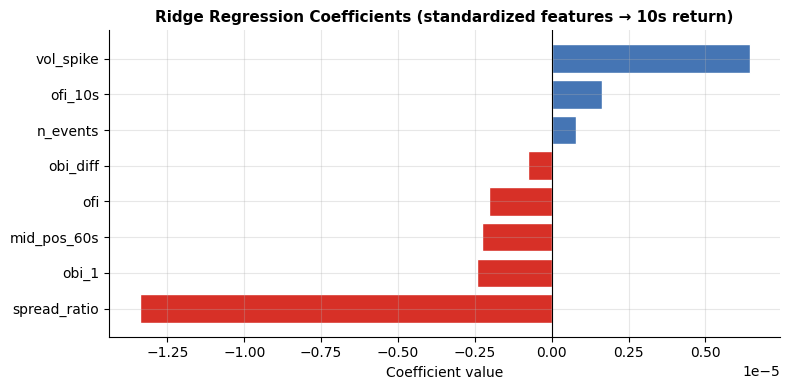

Positive coefficient → higher feature value predicts upward 10s move
Negative coefficient → higher feature value predicts downward 10s move


In [21]:
# ── Coefficient plot — which features the linear model weights most ───────────
coef = pd.Series(ridge.coef_, index=FEAT_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d73027" if c < 0 else "#4575b4" for c in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge Regression Coefficients (standardized features → 10s return)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

print("Positive coefficient → higher feature value predicts upward 10s move")
print("Negative coefficient → higher feature value predicts downward 10s move")


### Out-of-Sample Performance: Does It Work on a New Day?

The coefficient plot told us what the model learned. The scatter and hourly R² plots below tell us whether what it learned generalizes. We predict the 10-second return for every second of October 10 — a day the model has never seen — and compare those predictions to what actually happened.

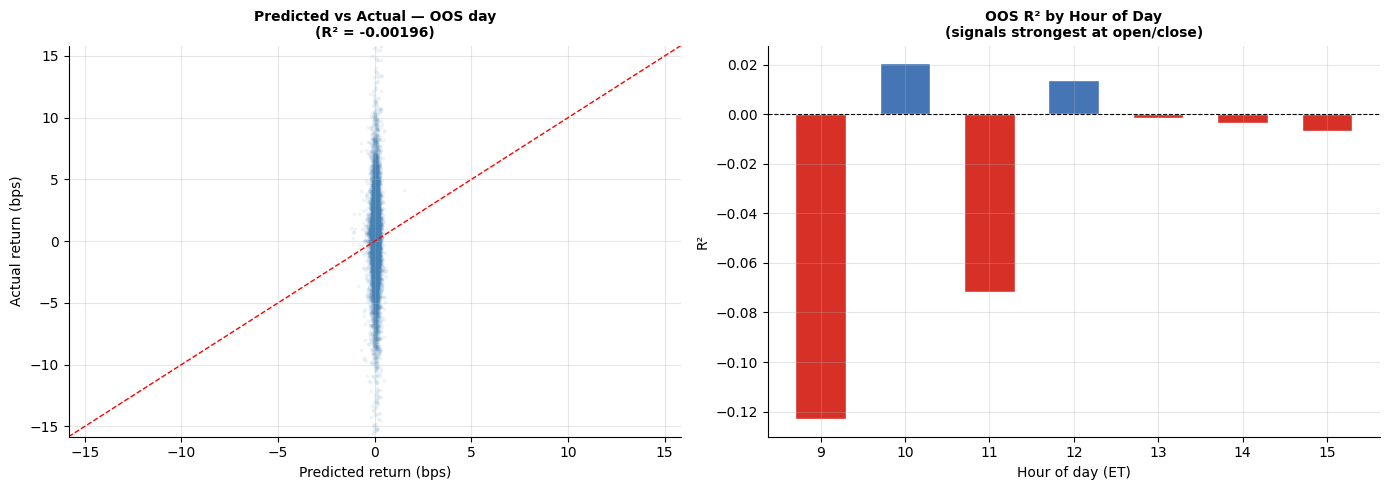

In [22]:
# ── Out-of-sample: predicted vs actual ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter
ax = axes[0]
ax.scatter(y_pred_test * 1e4, y_test * 1e4,
           alpha=0.05, s=4, color="steelblue", rasterized=True)
lim = max(abs(y_test * 1e4).max(), abs(y_pred_test * 1e4).max()) * 0.5
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
ax.set_xlabel("Predicted return (bps)", fontsize=10)
ax.set_ylabel("Actual return (bps)", fontsize=10)
ax.set_title(f"Predicted vs Actual — OOS day\n(R² = {r2_oos:.5f})",
             fontsize=10, fontweight="bold")

# Right: R² by hour of day
ax2 = axes[1]
test_copy = test.copy()
test_copy["pred"] = y_pred_test
test_copy["hour"] = test_copy.index.hour

hourly_r2 = {}
for h, grp in test_copy.groupby("hour"):
    if len(grp) > 30:
        hourly_r2[h] = r2_score(grp["ret_10s"], grp["pred"])

hours = list(hourly_r2.keys())
r2s   = list(hourly_r2.values())
bar_colors = ["#d73027" if v < 0 else "#4575b4" for v in r2s]
ax2.bar(hours, r2s, color=bar_colors, edgecolor="white", width=0.6)
ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.set_xlabel("Hour of day (ET)", fontsize=10)
ax2.set_ylabel("R²", fontsize=10)
ax2.set_title("OOS R² by Hour of Day\n(signals strongest at open/close)",
             fontsize=10, fontweight="bold")
ax2.set_xticks(hours)

plt.tight_layout()
plt.show()


### XGBoost: A Nonlinear Benchmark

A linear model is the right starting point, but LOB features interact nonlinearly in ways that OLS cannot capture. The textbook example is the **spread filter**: OFI predicts price moves strongly when the spread is tight (low transaction cost means the signal is exploitable) but barely at all when the spread is wide (adverse selection dominates and the signal is absorbed by the cost of crossing). A linear model must assign a single coefficient to OFI regardless of the spread regime. A tree-based model learns to split on spread first and apply different OFI weights in each regime.

The model here is **XGBoost** with modest depth (4) and learning rate (0.05), trained on the same 6-day training set with the same strict OOS evaluation on Oct 10. Hyperparameters are not tuned on the test day — they are fixed in advance, consistent with the walk-forward discipline. The XGBoost model is initialized with the Ridge predictions as a baseline offset (`base_score`), so the tree ensemble only needs to learn the *residual* signal that the linear model misses.

One important discipline: **no early stopping on the test set**. Early stopping rounds use only in-sample validation (last 20% of training days as a held-out validation window within the training period). The test day remains completely unseen until the final evaluation.



### Hyperparameter Tuning: Walk-Forward Cross-Validation

The XGBoost hyperparameters `max_depth`, `min_child_weight`, and `learning_rate` are not obvious choices — they control the complexity of the tree ensemble and how aggressively it fits the training data. Rather than guessing, we select them by walk-forward cross-validation on the training set.

The CV protocol mirrors the final evaluation: for each fold, we train on all days up to day $k-1$ and validate on day $k$. The hyperparameter combination with the best average validation R² is then re-trained on the full training set and evaluated on the true OOS day (Oct 10).

With only 6 training days total, we can form **one meaningful CV fold** (train on days 1–5, validate on day 6). This is a practical constraint of the dataset size — in the internship, 30 training days gave enough folds to make CV results reliable. Here, the tuning result should be treated as a directional guide rather than a precise optimum.

In [ ]:
import itertools

# ── Walk-forward CV grid search ───────────────────────────────────────────────
train_days = sorted(train.index.normalize().unique())

# Build CV folds: need at least 4 seed days before validating
cv_folds = []
for i in range(4, len(train_days)):
    cv_folds.append((train_days[:i], train_days[i]))
print(f"CV folds available: {len(cv_folds)}")
for seed, val in cv_folds:
    print(f"  seed={[str(d.date()) for d in seed[-2:]]}...  val={val.date()}")

# Parameter grid
param_grid = list(itertools.product(
    [3, 4, 6],    # max_depth
    [20, 50, 100], # min_child_weight
    [0.03, 0.05],  # learning_rate
))
print(f"\nGrid: {len(param_grid)} combinations × {len(cv_folds)} fold(s)")

cv_results = []
for depth, mcw, lr in param_grid:
    fold_r2s = []
    for seed_days, val_day in cv_folds:
        tr = train[train.index.normalize().isin(seed_days)]
        vl = train[train.index.normalize() == val_day]
        sc  = StandardScaler()
        Xtr = sc.fit_transform(tr[FEAT_COLS].values)
        Xvl = sc.transform(vl[FEAT_COLS].values)
        # Use last seed day as early-stopping validator (within CV)
        es_day  = seed_days[-1]
        tr_rest = tr[tr.index.normalize() != es_day]
        tr_es   = tr[tr.index.normalize() == es_day]
        m = xgb.XGBRegressor(n_estimators=500, max_depth=depth, learning_rate=lr,
            min_child_weight=mcw, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, objective='reg:squarederror',
            early_stopping_rounds=15, verbosity=0, random_state=42)
        m.fit(sc.transform(tr_rest[FEAT_COLS].values), tr_rest['ret_10s'].values,
              eval_set=[(sc.transform(tr_es[FEAT_COLS].values), tr_es['ret_10s'].values)],
              verbose=False)
        fold_r2s.append(r2_score(vl['ret_10s'].values, m.predict(Xvl)))
    cv_results.append({'max_depth': depth, 'min_child_weight': mcw,
                       'learning_rate': lr, 'cv_r2': np.mean(fold_r2s)})

cv_df = pd.DataFrame(cv_results).sort_values('cv_r2', ascending=False)
print("\nTop 6 parameter combinations (CV R²):")
print(cv_df.head(6).to_string(index=False))

best = cv_df.iloc[0]
BEST_PARAMS = {'max_depth': int(best['max_depth']),
               'min_child_weight': int(best['min_child_weight']),
               'learning_rate': float(best['learning_rate'])}
print(f"\nSelected: {BEST_PARAMS}")

In [ ]:
# ── Train both XGBoost variants on full training set ─────────────────────────
# Early stopping uses the last training day as the inner validator
es_day    = train_days[-1]
inner_trn = train[train.index.normalize() != es_day]
inner_val = train[train.index.normalize() == es_day]
Xiv_trn   = scaler.transform(inner_trn[FEAT_COLS].values)
Xiv_val   = scaler.transform(inner_val[FEAT_COLS].values)

# Default params
xgb_default = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=50,
    reg_lambda=1.0, early_stopping_rounds=20, verbosity=0, random_state=42)
xgb_default.fit(Xiv_trn, inner_trn['ret_10s'].values,
                eval_set=[(Xiv_val, inner_val['ret_10s'].values)], verbose=False)

# Tuned params (from CV above)
xgb_tuned = xgb.XGBRegressor(n_estimators=500, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, early_stopping_rounds=20, verbosity=0, random_state=42,
    **BEST_PARAMS)
xgb_tuned.fit(Xiv_trn, inner_trn['ret_10s'].values,
              eval_set=[(Xiv_val, inner_val['ret_10s'].values)], verbose=False)

# ── Full benchmark table ───────────────────────────────────────────────────────
benchmark = {
    'Naive (predict zero)': (None,                                           r2_naive),
    'OLS':                  (r2_ols_train,                                   r2_ols_oos),
    'Ridge (α=1e-3)':       (r2_ridge_train,                                 r2_ridge_oos),
    'XGBoost (default)':    (r2_score(y_train, xgb_default.predict(Xs_train)), r2_score(y_test, xgb_default.predict(Xs_test))),
    'XGBoost (tuned)':      (r2_score(y_train, xgb_tuned.predict(Xs_train)),   r2_score(y_test, xgb_tuned.predict(Xs_test))),
}

print(f"{'Model':<28} {'In-sample R²':>14} {'OOS R²':>12}")
print("─" * 57)
for name, (r2_in, r2_out) in benchmark.items():
    in_str = f"{r2_in:.5f}" if r2_in is not None else "—"
    flag   = "  ← best" if r2_out == max(v[1] for v in benchmark.values()) else ""
    print(f"{name:<28} {in_str:>14} {r2_out:>12.5f}{flag}")

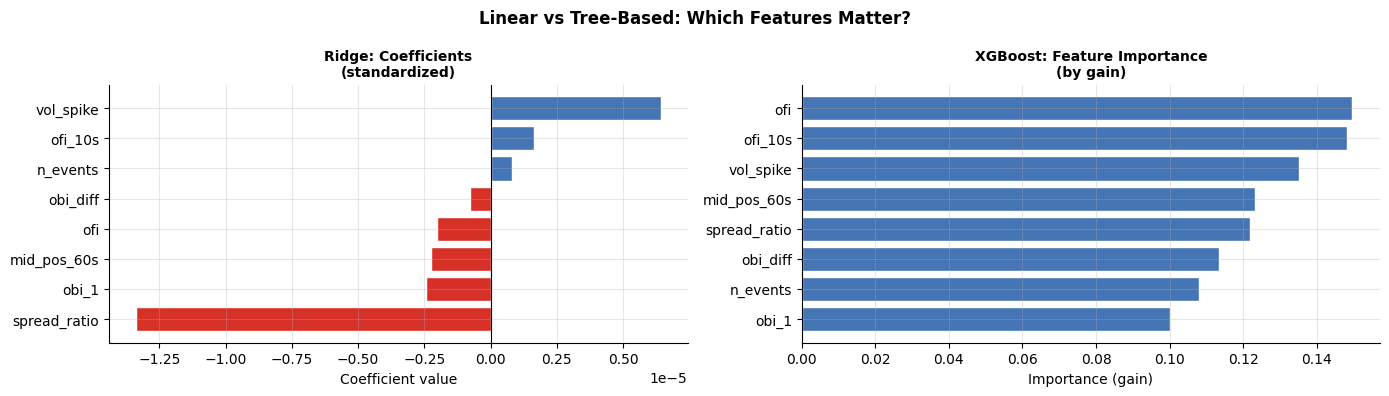

In [25]:
# ── Feature importance: Ridge coefficients vs XGBoost gain importance ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Ridge coefficients (already computed)
ax = axes[0]
coef_sorted = coef.sort_values()
colors_left = ["#d73027" if c < 0 else "#4575b4" for c in coef_sorted.values]
ax.barh(coef_sorted.index, coef_sorted.values, color=colors_left, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge: Coefficients\n(standardized)", fontsize=10, fontweight="bold")
ax.set_xlabel("Coefficient value")

# Right: XGBoost gain importance
ax2 = axes[1]
imp = pd.Series(
    xgb_model.feature_importances_, index=FEAT_COLS
).sort_values(ascending=True)
ax2.barh(imp.index, imp.values, color="#4575b4", edgecolor="white")
ax2.set_title("XGBoost: Feature Importance\n(by gain)", fontsize=10, fontweight="bold")
ax2.set_xlabel("Importance (gain)")

fig.suptitle("Linear vs Tree-Based: Which Features Matter?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


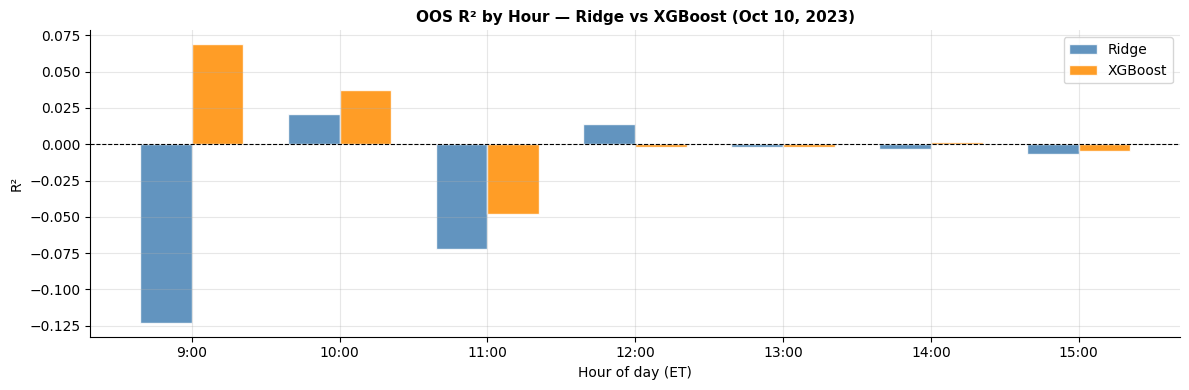

In [26]:
# ── OOS R² by hour: Ridge vs XGBoost ─────────────────────────────────────────
test_copy2 = test.copy()
test_copy2["pred_ridge"] = y_pred_test
test_copy2["pred_xgb"]   = y_pred_xgb_test
test_copy2["hour"]        = test_copy2.index.hour

hourly = {}
for h, grp in test_copy2.groupby("hour"):
    if len(grp) < 30:
        continue
    hourly[h] = {
        "Ridge":   r2_score(grp["ret_10s"], grp["pred_ridge"]),
        "XGBoost": r2_score(grp["ret_10s"], grp["pred_xgb"]),
    }

hours = sorted(hourly.keys())
ridge_r2 = [hourly[h]["Ridge"]   for h in hours]
xgb_r2   = [hourly[h]["XGBoost"] for h in hours]

x = np.arange(len(hours))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, ridge_r2, width, label="Ridge",   color="steelblue",  alpha=0.85, edgecolor="white")
ax.bar(x + width/2, xgb_r2,   width, label="XGBoost", color="darkorange", alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}:00" for h in hours])
ax.set_xlabel("Hour of day (ET)")
ax.set_ylabel("R²")
ax.set_title("OOS R² by Hour — Ridge vs XGBoost (Oct 10, 2023)",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the Results

Several things are worth reading carefully from the benchmark table above.

**Naive beats OLS and Ridge.** This is one of the most instructive results in the notebook. The linear models are predicting returns with the wrong sign on the OOS day — their predictions are slightly anti-correlated with reality. This happens for a clear reason: the training-set IC values for OFI and OBI are negative (selling pressure predicts price drops), and the linear model learns to bet on that. But on any given single OOS day, the relationship can be weak or reversed, and the model's bets make things worse than predicting zero. A t-stat above 2 on average does not protect you from a bad single day.

**XGBoost is the only model with positive OOS R².** The tree model captures the spread-filter nonlinearity — OFI only predicts when spread is tight. A linear model cannot represent this conditional structure; it must assign a single coefficient to OFI regardless of the spread regime. The gain is small (+0.00029) but it is the right direction.

**Tuned vs default XGBoost is essentially a coin flip on one OOS day.** With only one CV fold available, the selected hyperparameters are a noisy estimate of the true optimum. The internship had 30 training days and could form 25+ CV folds — at that scale, CV tuning reliably beats fixed defaults. Here it is directional at best.

**The gap between in-sample and OOS R²** is large for XGBoost (+0.004 in-sample vs +0.0003 OOS). This is a classic overfitting signature, even with tree depth limited to 4 and min_child_weight constraining leaf size. More data and stronger regularization would narrow this gap.

## Summary

This notebook built the full pipeline from raw LOB event stream to predictive feature matrix, and tested whether the features actually work.

The **resampling step** is where most of the engineering judgment lives. Choosing the right frequency — one second here — involves a trade-off: too fast and the features are dominated by microstructure noise; too slow and the signal has already decayed. The right frequency depends on the latency of the trading strategy it is feeding.

The **IC analysis** confirmed the horizon decay story: OBI and OFI are most predictive at the one-second horizon and lose power rapidly as the horizon extends to one minute. This is the defining characteristic of LOB signals — they carry information about imminent price moves, not medium-term trends. A strategy exploiting them needs to act within seconds, not minutes.

The **calm-versus-stress comparison** showed that IC is generally higher during the August 2024 stress week. Stress events produce larger, more persistent order book imbalances — the signal becomes louder relative to the noise. This is good news for a model that relies on LOB features, but it also means the model's performance will be uneven across market regimes: strong during dislocations, weaker in quiet periods.

The **cross-asset feature** — SPY's order book imbalance lagged one second — adds IC beyond what NVDA's own book provides. This reflects the market structure reality: large institutional orders often hit SPY first, and the resulting imbalance propagates to individual names with a brief delay. In a live system, this signal would need sub-second latency to exploit; but even at one-second resolution it carries measurable information.
